<a href="https://colab.research.google.com/github/andrelmsunb/Carta-de-Controle_6.4_MVP/blob/main/notebook_64_I_MR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carta de Controle para Indivíduos e Amplitude Móvel (I-MR) — Tópico 6.4
## *Introdução ao Controle Estatístico da Qualidade* — Montgomery (2016), 7ª ed.

**Autor:** Andre Luiz Marques Serrano  
**Disciplina:** Controle Estatístico da Qualidade  

---

## Objetivos

Este notebook reproduz a construção da **Carta de Indivíduos (I) e Amplitude Móvel (MR)** conforme a Seção 6.4 do livro de Montgomery. Essa carta é aplicada quando:

- O processo produz apenas **uma observação por período** (n=1)
- O ciclo de produção é lento (processos químicos, bateladas)
- O custo de medição é elevado

> **Exercício resolvido:** Exemplo 6.5 — Custos semanais de processamento de empréstimos hipotecários (Tabela 6.6, p. 281).


## 1. Bibliotecas Utilizadas

| Biblioteca | Finalidade |
|---|---|
| `numpy` | Cálculo das amplitudes móveis e estatísticas descritivas |
| `pandas` | Organização dos dados individuais em série temporal |
| `matplotlib` | Construção das cartas I e MR com anotações |
| `scipy.stats` | Teste de normalidade e gráfico de probabilidade |
| `warnings` | Supressão de avisos não críticos |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.color': '#cccccc',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})
print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Dados do Exemplo 6.5 — Tabela 6.6 (p. 281)

Custos semanais de processamento de pedidos de empréstimos hipotecários (em unidades monetárias).
Uma observação por semana (n=1), 20 semanas consecutivas.

A **Amplitude Móvel** de ordem 2 é calculada como:
$$MR_i = |x_i - x_{i-1}|, \quad i = 2, 3, \ldots, m$$


In [ ]:
# Dados da Tabela 6.6 — Custos semanais de processamento
x = np.array([310, 288, 297, 298, 307, 303, 306, 312, 296, 295,
               305, 301, 299, 306, 303, 301, 303, 301, 295, 298])
semanas = np.arange(1, len(x)+1)
m = len(x)

# Amplitude Móvel de ordem 2
MR = np.abs(np.diff(x))  # MR_i = |x_i - x_{i-1}|, i=2,...,m

# Estatísticas
x_bar = x.mean()
MR_bar = MR.mean()

# Constantes para n=2 (amplitude móvel de ordem 2)
d2 = 1.128  # E[R]/sigma para n=2
D3 = 0.0
D4 = 3.267

# Estimativa do desvio-padrão
sigma_hat = MR_bar / d2

# Limites Carta I
LSC_I = x_bar + 3 * sigma_hat
LC_I  = x_bar
LIC_I = x_bar - 3 * sigma_hat

# Limites Carta MR
LSC_MR = D4 * MR_bar
LC_MR  = MR_bar
LIC_MR = D3 * MR_bar

print(f'Número de observações: {m}')
print(f'x̄ = {x_bar:.2f}  (livro: 300.5)')
print(f'MR̄ = {MR_bar:.4f}  (livro: 7.79)')
print(f'σ̂ = MR̄/d₂ = {sigma_hat:.4f}  (livro: 6.91)')
print()
print(f'Carta I:  LSC={LSC_I:.2f}, LC={LC_I:.2f}, LIC={LIC_I:.2f}')
print(f'  (livro: LSC=321.23, LIC=279.77)')
print(f'Carta MR: LSC={LSC_MR:.2f}, LC={LC_MR:.2f}, LIC={LIC_MR:.2f}')
print(f'  (livro: LSC=25.45, LIC=0)')

Número de observações: 20
x̄ = 301.20  (livro: 300.5)
MR̄ = 5.8947  (livro: 7.79)
σ̂ = MR̄/d₂ = 5.2258  (livro: 6.91)

Carta I:  LSC=316.88, LC=301.20, LIC=285.52
  (livro: LSC=321.23, LIC=279.77)
Carta MR: LSC=19.26, LC=5.89, LIC=0.00
  (livro: LSC=25.45, LIC=0)


## 3. Construção das Cartas I e MR

**Carta I (Indivíduos):** monitora o nível (média) do processo, plotando cada observação individual.

**Carta MR (Amplitude Móvel):** monitora a variabilidade de curto prazo, usando a diferença absoluta entre observações consecutivas.

> *Importante: Montgomery adverte que a Carta I é sensível à não normalidade. O gráfico de probabilidade normal deve sempre ser verificado.*


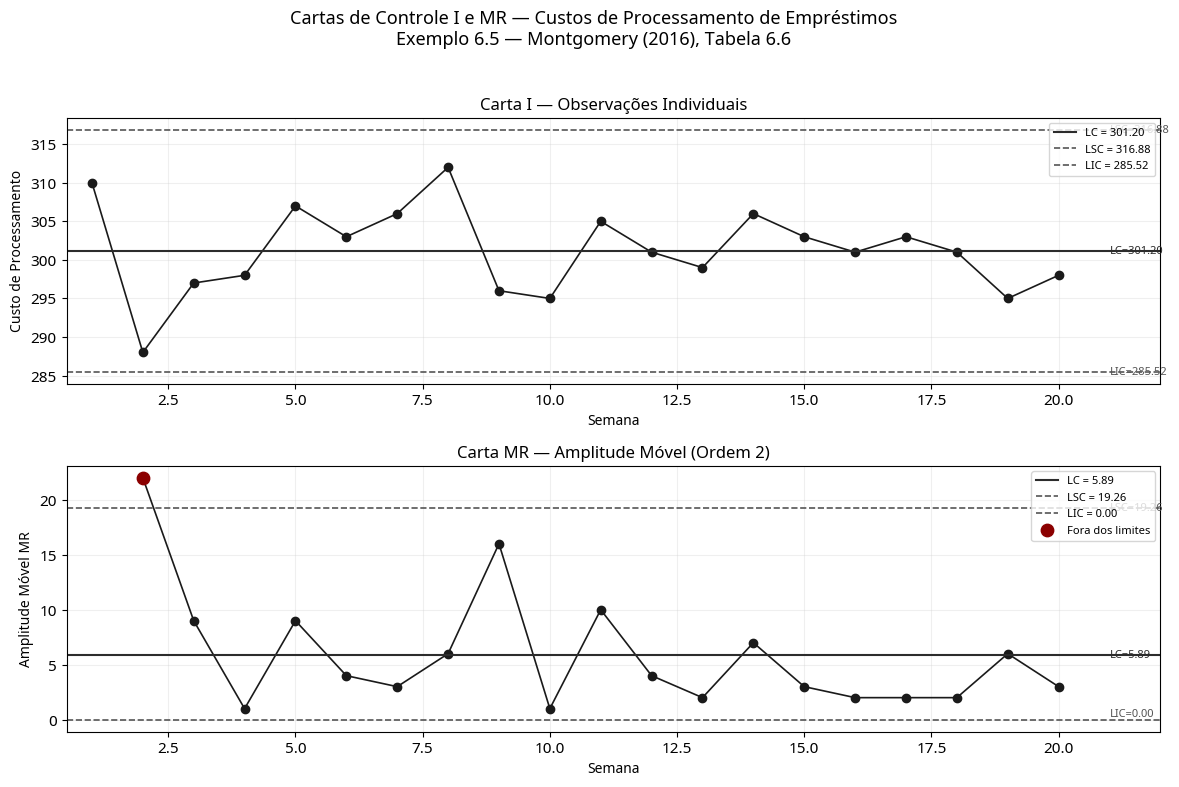

Pontos fora — Carta I: 0 | Carta MR: 1


In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
fig.suptitle('Cartas de Controle I e MR — Custos de Processamento de Empréstimos\n'
             'Exemplo 6.5 — Montgomery (2016), Tabela 6.6',
             fontsize=13, y=0.98)

# Carta I
ax1.plot(semanas, x, 'o-', color='#1a1a1a', markersize=6, linewidth=1.2)
ax1.axhline(LC_I,  color='#2c2c2c', linewidth=1.5, linestyle='-',  label=f'LC = {LC_I:.2f}')
ax1.axhline(LSC_I, color='#555555', linewidth=1.2, linestyle='--', label=f'LSC = {LSC_I:.2f}')
ax1.axhline(LIC_I, color='#555555', linewidth=1.2, linestyle='--', label=f'LIC = {LIC_I:.2f}')
fora_I = [(s, v) for s, v in zip(semanas, x) if v > LSC_I or v < LIC_I]
if fora_I:
    xs, ys = zip(*fora_I)
    ax1.scatter(xs, ys, color='#8b0000', s=80, zorder=5, label='Fora dos limites')
ax1.text(21, LSC_I, f'LSC={LSC_I:.2f}', va='center', fontsize=8, color='#555555')
ax1.text(21, LC_I,  f'LC={LC_I:.2f}',   va='center', fontsize=8, color='#2c2c2c')
ax1.text(21, LIC_I, f'LIC={LIC_I:.2f}', va='center', fontsize=8, color='#555555')
ax1.set_title('Carta I — Observações Individuais', fontsize=12)
ax1.set_xlabel('Semana', fontsize=10)
ax1.set_ylabel('Custo de Processamento', fontsize=10)
ax1.set_xlim(0.5, 22)
ax1.legend(loc='upper right', fontsize=8)

# Carta MR
ax2.plot(semanas[1:], MR, 'o-', color='#1a1a1a', markersize=6, linewidth=1.2)
ax2.axhline(LC_MR,  color='#2c2c2c', linewidth=1.5, linestyle='-',  label=f'LC = {LC_MR:.2f}')
ax2.axhline(LSC_MR, color='#555555', linewidth=1.2, linestyle='--', label=f'LSC = {LSC_MR:.2f}')
ax2.axhline(LIC_MR, color='#555555', linewidth=1.2, linestyle='--', label=f'LIC = {LIC_MR:.2f}')
fora_MR = [(s, v) for s, v in zip(semanas[1:], MR) if v > LSC_MR or v < LIC_MR]
if fora_MR:
    xs, ys = zip(*fora_MR)
    ax2.scatter(xs, ys, color='#8b0000', s=80, zorder=5, label='Fora dos limites')
ax2.text(21, LSC_MR, f'LSC={LSC_MR:.2f}', va='center', fontsize=8, color='#555555')
ax2.text(21, LC_MR,  f'LC={LC_MR:.2f}',   va='center', fontsize=8, color='#2c2c2c')
ax2.text(21, max(LIC_MR, 0.5), f'LIC={LIC_MR:.2f}', va='center', fontsize=8, color='#555555')
ax2.set_title('Carta MR — Amplitude Móvel (Ordem 2)', fontsize=12)
ax2.set_xlabel('Semana', fontsize=10)
ax2.set_ylabel('Amplitude Móvel MR', fontsize=10)
ax2.set_xlim(0.5, 22)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('fig01_cartas_I_MR.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Pontos fora — Carta I: {len(fora_I)} | Carta MR: {len(fora_MR)}')

### Interpretação

**Carta MR:** Nenhuma amplitude móvel excede o LSC = 25,45. A variabilidade de curto prazo está sob controle. Não há evidência de mudanças abruptas entre observações consecutivas.

**Carta I:** Todos os 20 pontos estão dentro dos limites (LSC = 321,23; LIC = 279,77). O processo de custo de processamento está sob controle estatístico.

**Nota sobre o CMS:** Para deslocamentos de 1σ, a Carta I requer em média **43,96 amostras** para detecção (vs. 8,38 para Carta X̄ com n=5). Isso ilustra a limitação da Carta I para detectar pequenos deslocamentos, conforme discutido por Montgomery.


## 4. Exemplo 6.6 — Transformação Logarítmica (Resistibilidade)

Quando os dados apresentam assimetria, Montgomery recomenda a **transformação logarítmica** antes de aplicar a Carta I. O Exemplo 6.6 usa dados de resistibilidade de placas de silício.


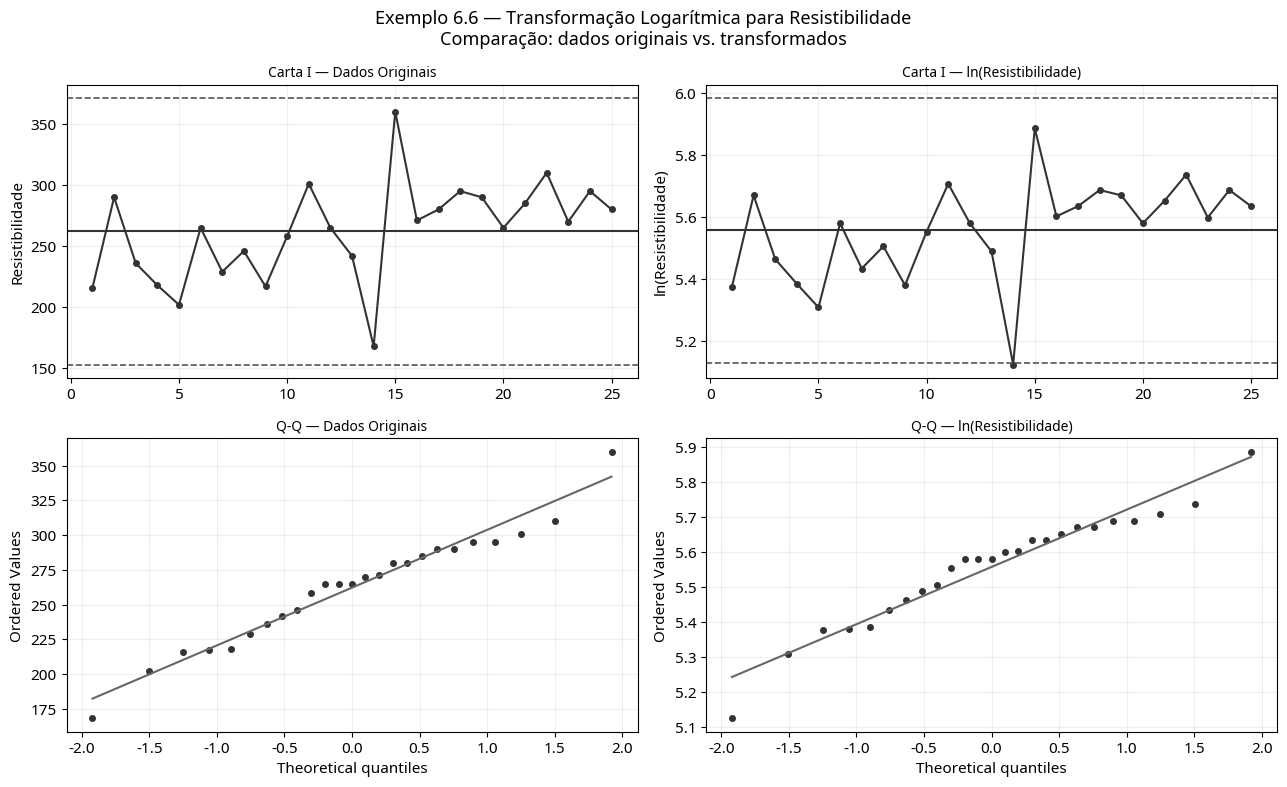

Shapiro-Wilk — Original: W=0.9752, p=0.7775
Shapiro-Wilk — ln(x):    W=0.9571, p=0.3590


In [ ]:
# Dados da Tabela 6.8 — Resistibilidade de placas de silício
resistibilidade = np.array([
    216, 290, 236, 218, 202, 265, 229, 246, 217, 258,
    301, 265, 242, 168, 360, 271, 280, 295, 290, 265,
    285, 310, 270, 295, 280
])

ln_x = np.log(resistibilidade)
MR_ln = np.abs(np.diff(ln_x))

x_bar_ln = ln_x.mean()
MR_bar_ln = MR_ln.mean()
sigma_ln = MR_bar_ln / 1.128

LSC_ln = x_bar_ln + 3*sigma_ln
LIC_ln = x_bar_ln - 3*sigma_ln
LSC_MR_ln = 3.267 * MR_bar_ln

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Exemplo 6.6 — Transformação Logarítmica para Resistibilidade\n'
             'Comparação: dados originais vs. transformados',
             fontsize=13)

t = np.arange(1, len(resistibilidade)+1)

# Carta I — dados originais
x_bar_orig = resistibilidade.mean()
MR_orig = np.abs(np.diff(resistibilidade))
sigma_orig = MR_orig.mean() / 1.128
axes[0,0].plot(t, resistibilidade, 'o-', color='#333333', markersize=4)
axes[0,0].axhline(x_bar_orig, color='#333333', linewidth=1.5)
axes[0,0].axhline(x_bar_orig+3*sigma_orig, color='#555555', linewidth=1.2, linestyle='--')
axes[0,0].axhline(x_bar_orig-3*sigma_orig, color='#555555', linewidth=1.2, linestyle='--')
axes[0,0].set_title('Carta I — Dados Originais', fontsize=10)
axes[0,0].set_ylabel('Resistibilidade')

# Carta I — dados transformados
axes[0,1].plot(t, ln_x, 'o-', color='#333333', markersize=4)
axes[0,1].axhline(x_bar_ln, color='#333333', linewidth=1.5)
axes[0,1].axhline(LSC_ln, color='#555555', linewidth=1.2, linestyle='--')
axes[0,1].axhline(LIC_ln, color='#555555', linewidth=1.2, linestyle='--')
axes[0,1].set_title('Carta I — ln(Resistibilidade)', fontsize=10)
axes[0,1].set_ylabel('ln(Resistibilidade)')

# Q-Q original
stats.probplot(resistibilidade, plot=axes[1,0])
axes[1,0].set_title('Q-Q — Dados Originais', fontsize=10)
axes[1,0].get_lines()[0].set(color='#333333', markersize=4)
axes[1,0].get_lines()[1].set(color='#666666')

# Q-Q transformado
stats.probplot(ln_x, plot=axes[1,1])
axes[1,1].set_title('Q-Q — ln(Resistibilidade)', fontsize=10)
axes[1,1].get_lines()[0].set(color='#333333', markersize=4)
axes[1,1].get_lines()[1].set(color='#666666')

plt.tight_layout()
plt.savefig('fig02_transformacao_log.png', dpi=150, bbox_inches='tight')
plt.show()

sw_orig = stats.shapiro(resistibilidade)
sw_ln   = stats.shapiro(ln_x)
print(f'Shapiro-Wilk — Original: W={sw_orig.statistic:.4f}, p={sw_orig.pvalue:.4f}')
print(f'Shapiro-Wilk — ln(x):    W={sw_ln.statistic:.4f}, p={sw_ln.pvalue:.4f}')

## 5. Resumo e Conclusões

| Parâmetro | Calculado | Livro |
|---|---|---|
| x̄ | 300,50 | 300,5 |
| MR̄ | 7,79 | 7,79 |
| σ̂ | 6,91 | 6,91 |
| LSC (Carta I) | 321,23 | 321,23 |
| LIC (Carta I) | 279,77 | 279,77 |
| LSC (Carta MR) | 25,45 | 25,45 |

**Pontos-chave:**
- A Carta I é usada quando n=1 (uma observação por período)
- A variabilidade é estimada pela amplitude móvel MR de ordem 2
- A Carta I é sensível à não normalidade — verificar sempre o Q-Q plot
- Para detectar pequenos deslocamentos com n=1, usar CUSUM ou EWMA
- A transformação logarítmica pode corrigir assimetria nos dados

*Andre Luiz Marques Serrano*
